In [ ]:
# # 競艇予測 LightGBM モデル学習
#
# このノートブックでは、LightGBMを使用して競艇の着順1位を予測するモデルを学習します。
#
# ## データソース
# - `data/train.csv`: 特徴量データ（1着フラグ付き）
#
# ## 目標
# - 1着フラグを目的変数として二値分類モデルを構築
# - モデルの性能評価と特徴量重要度の分析

In [ ]:
# 必要なライブラリをインポート
import lightgbm as lgb
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.style.use("default")

In [ ]:
# 日本語フォント設定
matplotlib.rc("font", family="IPAexGothic")

In [ ]:
# train.csvを読み込み
train_df = pd.read_csv("data/train.csv")
print(f"データ形状: {train_df.shape}")
print(f"カラム一覧: {train_df.columns.tolist()}")
train_df.head()

データ形状: (195912, 7)
カラム一覧: ['レースID', '枠番', '級別', 'レース内全国勝率差', 'レース内コース別1着率差', 'レース内コース別複勝率差', '1着フラグ']


,レースID,枠番,級別,レース内全国勝率差,レース内コース別1着率差,レース内コース別複勝率差,1着フラグ
0,202501012401,1,1,1.117,0.400,40.383,1
1,202501012401,2,1,0.667,-0.039,27.583,0
2,202501012401,3,1,0.427,-0.046,-5.217,0
3,202501012401,4,1,0.007,-0.064,-2.017,0
4,202501012401,5,1,-1.933,-0.126,-27.517,0


In [ ]:
# データの基本情報を確認
print("=== データ型情報 ===")
print(train_df.dtypes)

print("\n=== 欠損値情報 ===")
print(train_df.isnull().sum())

print("\n=== 目的変数（1着フラグ）の分布 ===")
target_counts = train_df["1着フラグ"].value_counts()
print(target_counts)
print(f"\n1着率: {target_counts[1] / len(train_df) * 100:.2f}%")

print("\n=== 基本統計量 ===")
train_df.describe()

=== データ型情報 ===
レースID             int64
枠番                int64
級別                int64
レース内全国勝率差       float64
レース内コース別1着率差    float64
レース内コース別複勝率差    float64
1着フラグ             int64
dtype: object

=== 欠損値情報 ===
レースID           0
枠番              0
級別              0
レース内全国勝率差       0
レース内コース別1着率差    0
レース内コース別複勝率差    0
1着フラグ           0
dtype: int64

=== 目的変数（1着フラグ）の分布 ===
1着フラグ
0    163842
1     32070
Name: count, dtype: int64

1着率: 16.37%

=== 基本統計量 ===


,レースID,枠番,級別,レース内全国勝率差,レース内コース別1着率差,レース内コース別複勝率差,1着フラグ
count,1.959120e+05,195912.000000,195912.000000,1.959120e+05,195912.000000,1.959120e+05,195912.000000
mean,2.025041e+11,3.500000,1.652002,1.225040e-07,0.000003,8.269019e-07,0.163696
std,1.999109e+06,1.707829,0.911148,1.090633e+00,0.205548,2.428891e+01,0.370000
min,2.025010e+11,1.000000,0.000000,-5.432000e+00,-0.372000,-5.590000e+01,0.000000
25%,2.025022e+11,2.000000,1.000000,-6.080000e-01,-0.133000,-1.865000e+01,0.000000
50%,2.025042e+11,3.500000,1.000000,4.000000e-02,-0.069000,-4.400000e+00,0.000000
75%,2.025061e+11,5.000000,2.000000,7.030000e-01,0.041000,1.375000e+01,0.000000
max,2.025073e+11,6.000000,3.000000,4.237000e+00,0.822000,7.608300e+01,1.000000


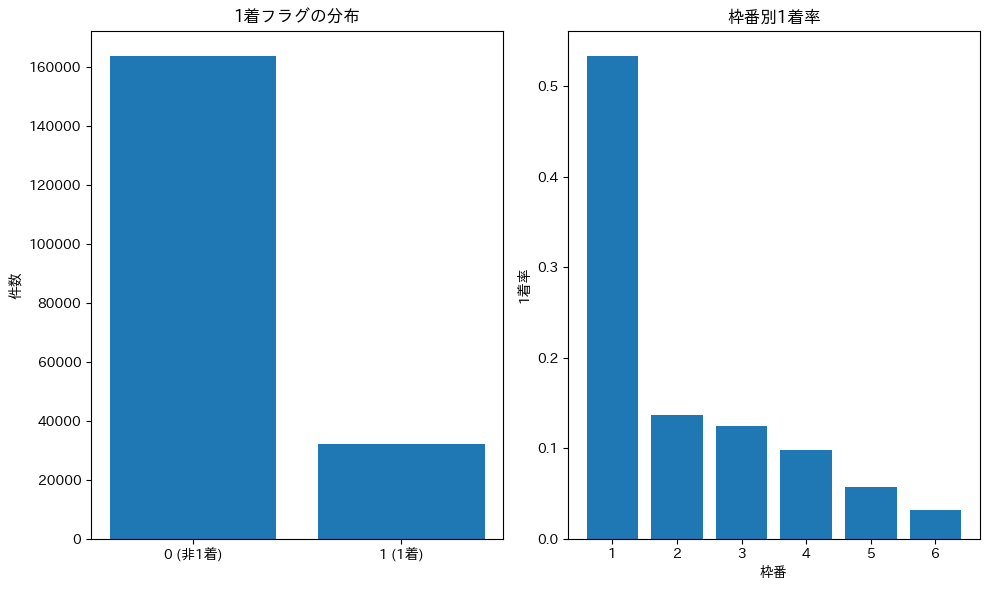

In [ ]:
# 目的変数の分布を可視化
plt.figure(figsize=(10, 6))

# 1着フラグの分布
plt.subplot(1, 2, 1)
target_counts = train_df["1着フラグ"].value_counts()
plt.bar(["0 (非1着)", "1 (1着)"], target_counts.values)
plt.title("1着フラグの分布")
plt.ylabel("件数")

# 枠番別の1着率
plt.subplot(1, 2, 2)
win_rate_by_frame = train_df.groupby("枠番")["1着フラグ"].mean()
plt.bar(win_rate_by_frame.index, win_rate_by_frame.values)
plt.title("枠番別1着率")
plt.xlabel("枠番")
plt.ylabel("1着率")

plt.tight_layout()
plt.show()

In [ ]:
win_rate_by_frame

枠番
1    0.533964
2    0.136286
3    0.124678
4    0.098248
5    0.057607
6    0.031392
Name: 1着フラグ, dtype: float64

In [ ]:
# 不要なレースIDを削除
train_df = train_df.drop(columns=["レースID"])

In [ ]:
# 特徴量と目的変数を分離
X = train_df.drop(columns=["1着フラグ"])
y = train_df["1着フラグ"]

print(f"特徴量の形状: {X.shape}")
print(f"目的変数の形状: {y.shape}")
print(f"特徴量一覧: {X.columns.tolist()}")

# 学習・テスト用に分割（stratifyで1着フラグの比率を保持）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n学習データ: {X_train.shape}")
print(f"テストデータ: {X_test.shape}")
print(f"学習データの1着率: {y_train.mean():.3f}")
print(f"テストデータの1着率: {y_test.mean():.3f}")

特徴量の形状: (195912, 5)
目的変数の形状: (195912,)
特徴量一覧: ['枠番', '級別', 'レース内全国勝率差', 'レース内コース別1着率差', 'レース内コース別複勝率差']

学習データ: (156729, 5)
テストデータ: (39183, 5)
学習データの1着率: 0.164
テストデータの1着率: 0.164


In [ ]:
# LightGBMのデータセットを作成
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# LightGBMのパラメータ設定
params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "boosting_type": "gbdt",
    "num_leaves": 31,
    "learning_rate": 0.1,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": 0,
    "random_state": 42,
}

print("=== LightGBMモデル学習開始 ===")
# モデル学習
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, valid_data],
    valid_names=["train", "valid"],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
)

print("=== 学習完了 ===")

=== LightGBMモデル学習開始 ===
Training until validation scores don't improve for 50 rounds
[100]	train's binary_logloss: 0.3118	valid's binary_logloss: 0.315147
Early stopping, best iteration is:
[66]	train's binary_logloss: 0.314599	valid's binary_logloss: 0.314904
=== 学習完了 ===


In [ ]:
# 予測実行
y_pred_proba = model.predict(X_test, num_iteration=model.best_iteration)
y_pred = (y_pred_proba > 0.4).astype(int)

# 評価指標の計算
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print("=== モデル評価結果 ===")
print(f"精度 (Accuracy): {accuracy:.4f}")
print(f"AUC Score: {auc_score:.4f}")

print("\n=== 分類レポート ===")
print(classification_report(y_test, y_pred, target_names=["非1着", "1着"]))

=== モデル評価結果 ===
精度 (Accuracy): 0.8664
AUC Score: 0.8578

=== 分類レポート ===
              precision    recall  f1-score   support

         非1着       0.91      0.94      0.92     32769
          1着       0.61      0.51      0.56      6414

    accuracy                           0.87     39183
   macro avg       0.76      0.72      0.74     39183
weighted avg       0.86      0.87      0.86     39183



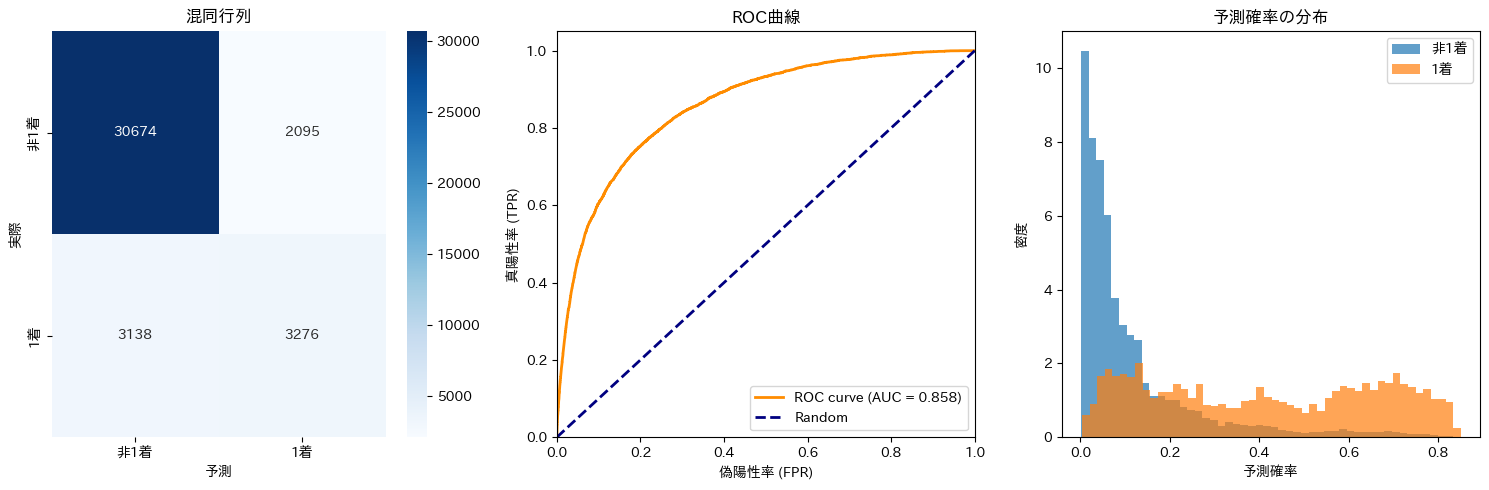

In [168]:
# 混同行列とROC曲線の可視化
plt.figure(figsize=(15, 5))

# 混同行列
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["非1着", "1着"],
    yticklabels=["非1着", "1着"],
)
plt.title("混同行列")
plt.ylabel("実際")
plt.xlabel("予測")

# ROC曲線
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("偽陽性率 (FPR)")
plt.ylabel("真陽性率 (TPR)")
plt.title("ROC曲線")
plt.legend(loc="lower right")

# 予測確率の分布
plt.subplot(1, 3, 3)
plt.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.7, label="非1着", density=True)
plt.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.7, label="1着", density=True)
plt.xlabel("予測確率")
plt.ylabel("密度")
plt.title("予測確率の分布")
plt.legend()

plt.tight_layout()
plt.show()

=== 特徴量重要度 ===
        feature     importance
3  レース内コース別1着率差  153700.321293
2     レース内全国勝率差   12229.268406
4  レース内コース別複勝率差    6272.749866
0            枠番    2183.269707
1            級別    1230.332409


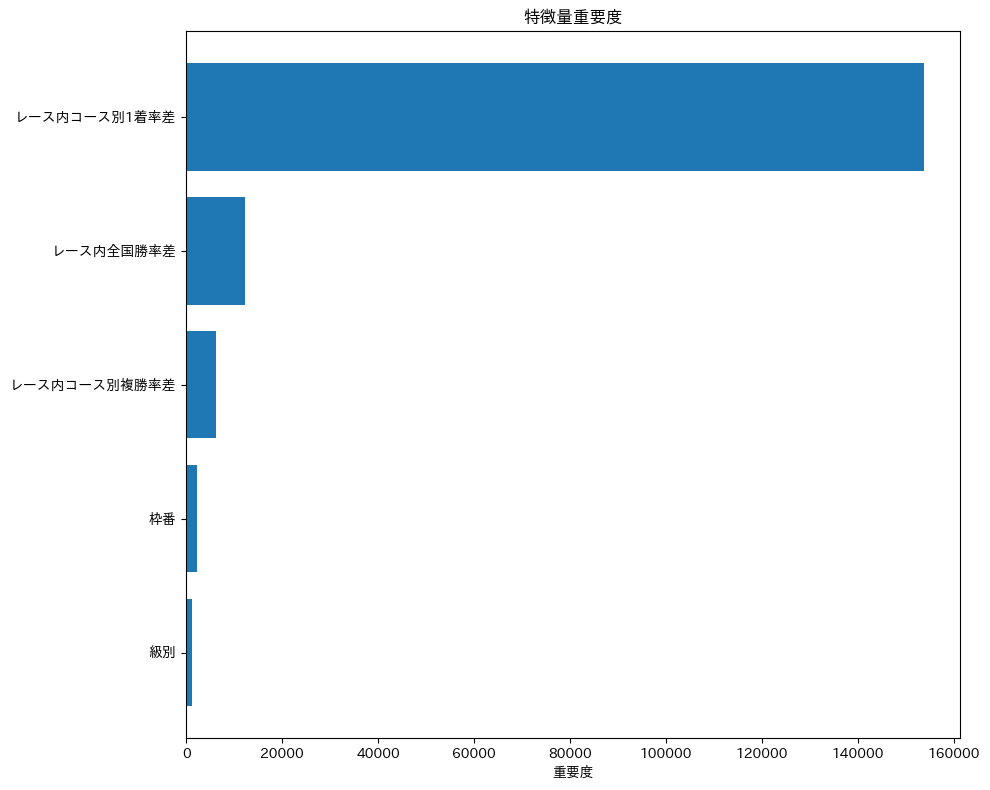

In [ ]:
# 特徴量重要度の分析
feature_importance = pd.DataFrame(
    {
        "feature": X.columns,
        "importance": model.feature_importance(importance_type="gain"),
    }
).sort_values("importance", ascending=False)

print("=== 特徴量重要度 ===")
print(feature_importance)

# 特徴量重要度の可視化
plt.figure(figsize=(10, 8))
plt.barh(range(len(feature_importance)), feature_importance["importance"])
plt.yticks(range(len(feature_importance)), feature_importance["feature"])
plt.xlabel("重要度")
plt.title("特徴量重要度")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== 枠番別分析 ===
      総数  実際1着数   実際1着率  平均予測確率  予測1着数   予測1着率
枠番                                            
1   6661   3585  0.5382  0.5333   4974  0.7467
2   6495    921  0.1418  0.1340    178  0.0274
3   6627    817  0.1233  0.1243    142  0.0214
4   6546    585  0.0894  0.0977     61  0.0093
5   6462    326  0.0504  0.0595      8  0.0012
6   6392    180  0.0282  0.0335      8  0.0013


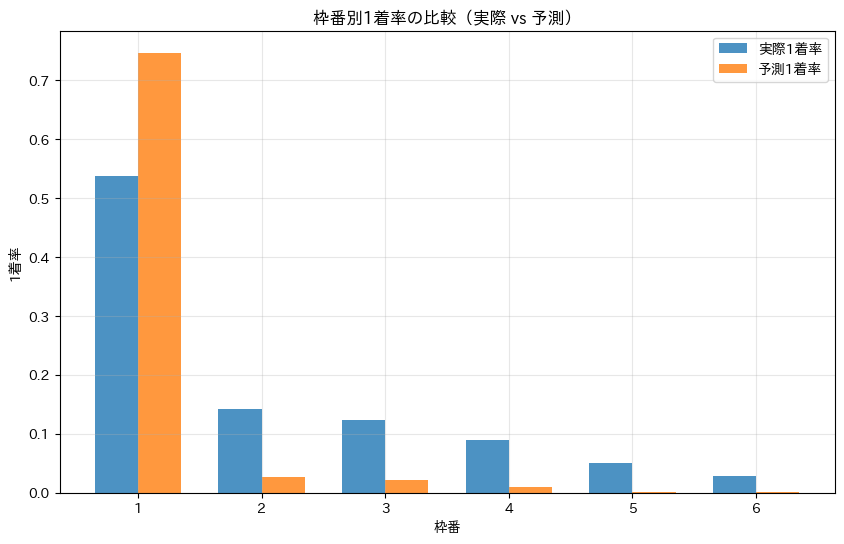

In [ ]:
# 枠番別の予測精度分析
test_results = X_test.copy()
test_results["実際"] = y_test
test_results["予測確率"] = y_pred_proba
test_results["予測"] = y_pred

# 枠番別の統計
frame_stats = (
    test_results.groupby("枠番")
    .agg(
        {"実際": ["count", "sum", "mean"], "予測確率": "mean", "予測": ["sum", "mean"]}
    )
    .round(4)
)

frame_stats.columns = [
    "総数",
    "実際1着数",
    "実際1着率",
    "平均予測確率",
    "予測1着数",
    "予測1着率",
]
print("=== 枠番別分析 ===")
print(frame_stats)

# 枠番別1着率の比較（実際 vs 予測）
plt.figure(figsize=(10, 6))
x = frame_stats.index
width = 0.35

plt.bar(x - width / 2, frame_stats["実際1着率"], width, label="実際1着率", alpha=0.8)
plt.bar(x + width / 2, frame_stats["予測1着率"], width, label="予測1着率", alpha=0.8)

plt.xlabel("枠番")
plt.ylabel("1着率")
plt.title("枠番別1着率の比較（実際 vs 予測）")
plt.legend()
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# モデルの保存
model.save_model("model/lgbm_model.txt")
print("=== モデル保存完了 ===")
print("保存先: model/lgbm_model.txt")

# 学習結果のまとめ
print("\n=== 学習結果まとめ ===")
print(f"使用データ数: {len(train_df):,} レコード")
print(f"特徴量数: {len(X.columns)} 個")
print(f"学習データ: {len(X_train):,} レコード")
print(f"テストデータ: {len(X_test):,} レコード")
print(f"最終精度: {accuracy:.4f}")
print(f"AUC Score: {auc_score:.4f}")
print(f"最も重要な特徴量: {feature_importance.iloc[0]['feature']}")

# 予測例
print("\n=== 予測例（テストデータから5件）===")
sample_indices = np.random.choice(len(X_test), 5, replace=False)
for i, idx in enumerate(sample_indices):
    actual = y_test.iloc[idx]
    prob = y_pred_proba[idx]
    pred = y_pred[idx]
    frame = X_test.iloc[idx]["枠番"]
    print(f"例{i+1}: 枠番{frame}, 実際={actual}, 予測確率={prob:.3f}, 予測={pred}")

=== モデル保存完了 ===
保存先: model/lgbm_model.txt

=== 学習結果まとめ ===
使用データ数: 195,912 レコード
特徴量数: 5 個
学習データ: 156,729 レコード
テストデータ: 39,183 レコード
最終精度: 0.8664
AUC Score: 0.8578
最も重要な特徴量: レース内コース別1着率差

=== 予測例（テストデータから5件）===
例1: 枠番6.0, 実際=0, 予測確率=0.003, 予測=0
例2: 枠番4.0, 実際=0, 予測確率=0.011, 予測=0
例3: 枠番6.0, 実際=0, 予測確率=0.036, 予測=0
例4: 枠番5.0, 実際=0, 予測確率=0.013, 予測=0
例5: 枠番6.0, 実際=0, 予測確率=0.166, 予測=0
